In [1]:
import numpy as np
import seaborn as sns 
import matplotlib.pyplot as plt

In [2]:
import sympy as sp

In [3]:
x,y = sp.symbols ( 'x y' ) 

In [4]:
f = x**2 + y**2 - 25
f

x**2 + y**2 - 25

In [5]:
sp.idiff( f,y,x) 

-x/y

In [6]:
f1 = 2*x -1 
f1

2*x - 1

In [7]:
f1 = sp.lambdify( x,f1, modules = 'numpy' ) 


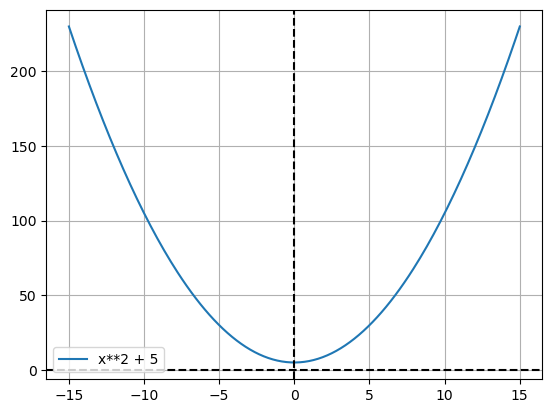

In [8]:
#Creating the functin 

f_x = x**2 + 5 
x_v = np.linspace ( -15,15,200) 
f_x = sp.lambdify(x, f_x) 
val = f_x( x_v ) 
plt.figure() 
sns.lineplot(x=x_v, y=val , label= 'x**2 + 5')
plt.axvline( 0 , color = 'black' , linestyle = 'dashed' )
plt.axhline( 0 , color = 'black' , linestyle = 'dashed' ) 
plt.grid()
plt.show() 

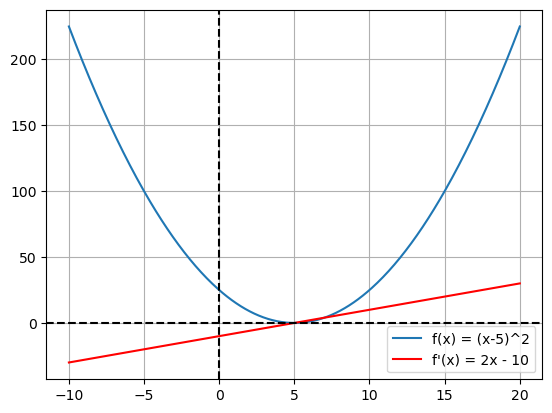

In [9]:
x = sp.symbols('x')
f_expr = (x - 5) ** 2
df_expr = sp.diff(f_expr, x)

f_x = sp.lambdify(x, f_expr, 'numpy')
d_x = sp.lambdify(x, df_expr, 'numpy')

x_v = np.linspace(-10, 20, 400)
_y = f_x(x_v)
__y = d_x(x_v)
plt.figure() 
sns.lineplot(x=x_v, y=_y, label="f(x) = (x-5)^2")
sns.lineplot(x=x_v, y=__y, color="red", label="f'(x) = 2x - 10")
plt.axvline(0, color="black", linestyle="dashed")
plt.axhline(0, color="black", linestyle="dashed")
plt.grid(True)
plt.legend()
plt.show()

In [10]:
from sympy import Symbol, S, Interval, sin, maximum

x = Symbol('x')
f = -x**2 + 4*x + 7

# Global maximum over all real numbers
max_val_global = maximum(f, x, S.Reals)
print(max_val_global)  # Output: 11

# Local maximum within a specific interval [0, 1]
max_val_interval = maximum(f, x, Interval(0, 1))
print(max_val_interval)  # Output: 10


11
10


In [11]:
f = sp.lambdify ( x, f ) 



In [12]:
f(11) 

-70

#  Newton raphson

In [13]:
# Definig the function 

import numpy as np
import matplotlib.pyplot as plt



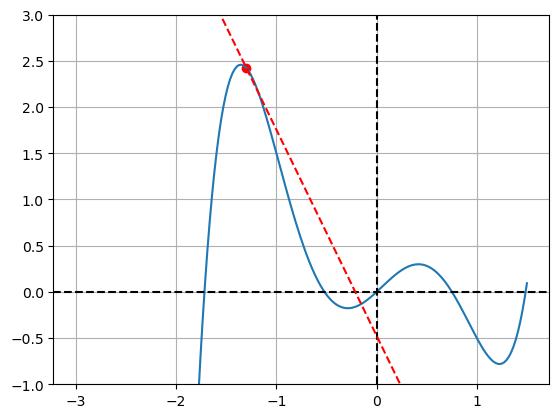

In [14]:
def f ( x ) : 
    return x**5 - 3*x**3 + 0.5*x**2 + x

def f_prime ( x ) : 
    return 5*x**4 - 9*x**2 + x

domain = np.linspace( -3 , 1.5 , 200) 
output = f( domain )
point = -1.3
xo = f(point) 
line = xo + f_prime(point)* ( domain - point) 
plt.figure() 
plt.plot( domain , output) 
plt.scatter ( point , xo , color = 'red')
plt.axhline ( 0 , color = 'black' , linestyle = '--' ) 
plt.axvline ( 0 , color = 'black' , linestyle = '--' ) 
plt.plot( domain , line , color = 'red' , linestyle ='--') 
plt.ylim( -1 , 3 ) 
plt.grid ( True ) 
plt.show() 

In [15]:
def f(x):
    return x**5 - 3*x**3 + 0.5*x**2 + x

def f_prime(x):
    return 5*x**4 - 9*x**2 + x + 1   

def newton(iter_num, xo =None ) :
    x_s = []
    if xo is None:
        xo = np.random.choice(np.linspace(-2, 2, 200))
    x_s.append(xo)
    for i in range(iter_num):
        f_xo = f(xo)
        dx = f_prime(xo)
        if abs(dx) < 1e-12:
            break
        xn = xo - (f_xo / dx)
        x_s.append(xn)
        xo = xn   
    
    return x_s


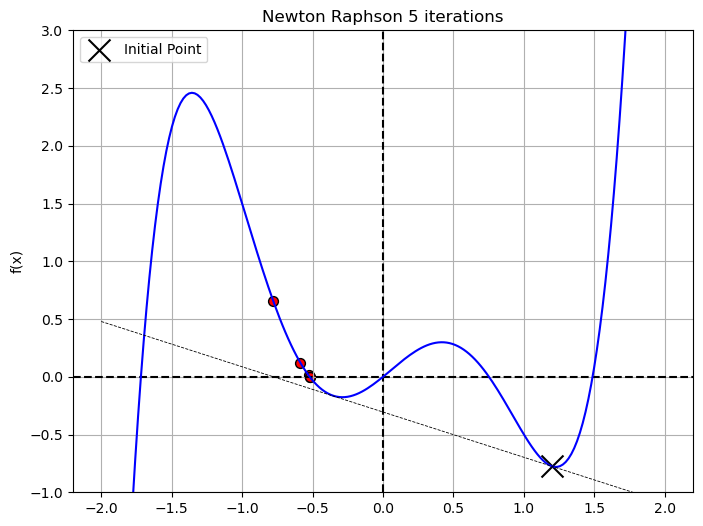

In [16]:



x = np.linspace( -2 , 2 , 200) 
y = f( x )

xn  = newton ( 5 , xo = 1.2) 
f_xn = [ ] 
for i in  range(len( xn ) )    : 
    val = f( xn[i]) 
    f_xn.append(val)

line = f( xn[0] ) + ( f_prime ( xn[0]) * ( x - xn[0]) )


plt.figure( figsize = (8,6) ) 
plt.axhline ( 0 , color = 'black' , linestyle = '--' ) 
plt.axvline ( 0 , color = 'black' , linestyle = '--' ) 
plt.plot( x , y  , color = 'blue' ) 
plt.scatter( xn[0] , f_xn[0] , color = 'black' , s =  250,  label ='Initial Point' , marker= 'x' ) 
plt.legend ( ) 
plt.title( 'Newton Raphson 5 iterations') 
plt.ylabel( 'f(x)' ) 
plt.scatter ( xn[1:] , f_xn[1:] , color = 'red' , s = 50  , edgecolor = 'black'  ) 
plt.plot( x , line , color = 'black' , linewidth = 0.6 , linestyle = 'dashed') 
plt.ylim( -1 , 3 ) 
plt.grid ( True ) 
plt.show() 

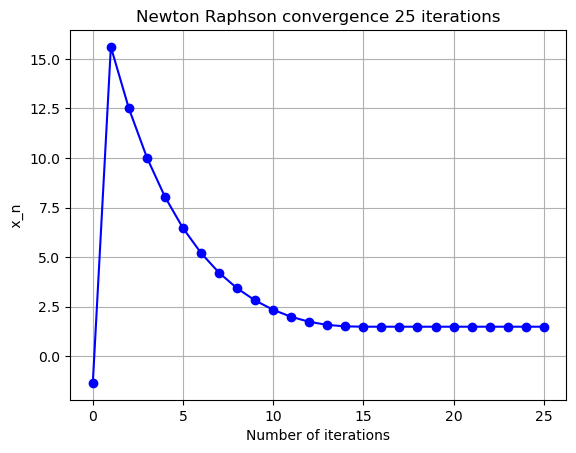

In [17]:
xn  = newton ( 25 , xo = -1.35 ) 
f_xn = [ ] 
for i in  range(len( xn ) )    : 
    val = f( xn[i]) 
    f_xn.append(val)

plt.figure() 
plt.plot ( range(len(xn)) ,  xn , 'bo-' ) 

plt.title('Newton Raphson convergence 25 iterations') 
plt.grid ( True ) 
plt.xlabel( 'Number of iterations') 
plt.ylabel(  ' x_n ' ) 
plt.show() 


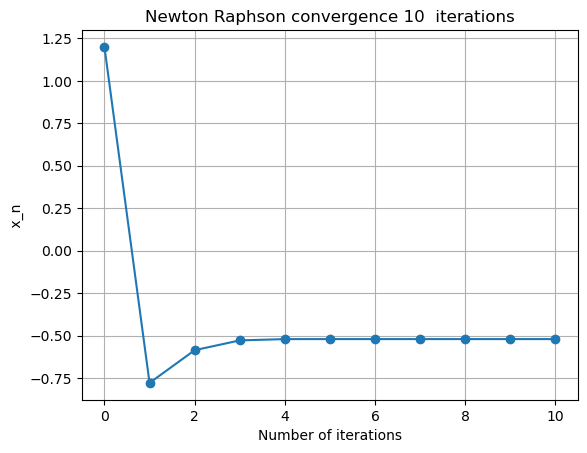

In [18]:
xn  = newton ( 10  ,1.2 ) 
f_xn = [ ] 
for i in  range(len( xn ) )    : 
    val = f( xn[i]) 
    f_xn.append(val)

plt.figure() 
plt.plot ( range(len(xn))    , xn , marker = 'o' ) 

plt.title('Newton Raphson convergence 10  iterations') 
plt.grid ( True ) 
plt.xlabel( 'Number of iterations') 
plt.ylabel(  ' x_n ' ) 
plt.show() 


# Newton Raphson for Optimization

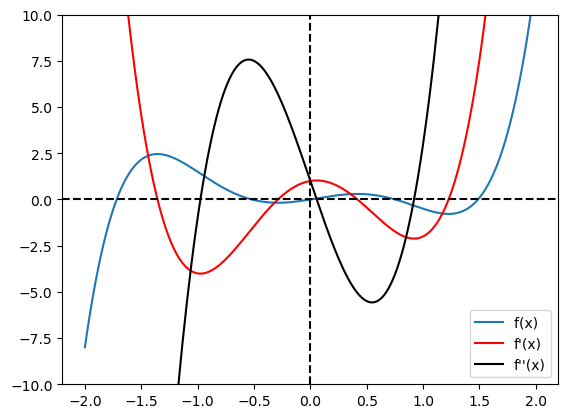

In [19]:
def f_double_prime ( x) : 
    return 20*x**3 - 18*x**1 + 1 


fx = f( x) 
f_x = f_prime ( x) 
f_xx = f_double_prime( x) 

plt.figure ( ) 
plt.plot ( x , fx  , label = "f(x) ") 
plt.plot( x, f_x , label = "f'(x)" , color = 'red') 
plt.plot( x, f_xx , label = "f''(x)" , color = 'black') 
plt.axhline ( 0 , color = 'black' , linestyle = '--' ) 
plt.axvline ( 0 , color = 'black' , linestyle = '--' ) 
plt.ylim( -10, 10 ) 
plt.legend() 
plt.show() 

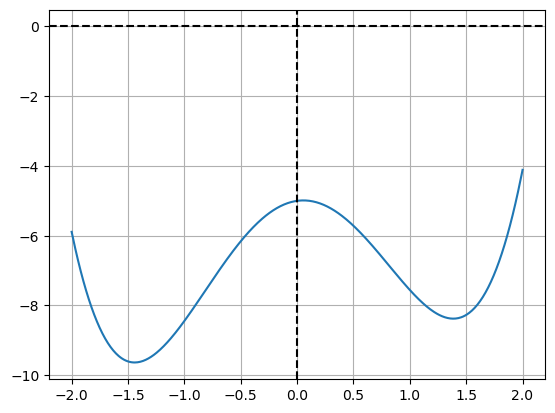

In [20]:
def f(x) : 
    return x**4  - 4*x**2 + (4/9)*x - 5 

def f_prime ( x ) : 
    return  4*x**3 - 8*x + (4/9 ) 

def f_2_prime ( x )  : 
    return 12*x**2 - 8 

def newton_optimize ( iter_num , xo = None ) : 
    x_s = [ ] 
    if xo == None :
        xo = np.random.choice ( np.linspace ( -2,2 , 500 ) , size = 1 ) 
    x_s.append(xo ) 

    for i in range ( iter_num ) : 
        f_x = f_prime(xo ) 
        f_xx = f_2_prime( xo ) 
        if f_xx == 0 : 
            break
        xn = xo - ( f_x / f_xx ) 
        x_s.append( xn ) 
        xo = xn

    return x_s 

#Now optimizing the function 

plt.figure( ) 
x = np.linspace ( -2,2 , 500 )
fx = f(x) 

plt.plot( x,fx)
plt.axhline ( 0 , color = 'black' , linestyle = '--' ) 
plt.axvline ( 0 , color = 'black' , linestyle = '--' ) 
plt.grid ( True ) 
plt.show() 
    

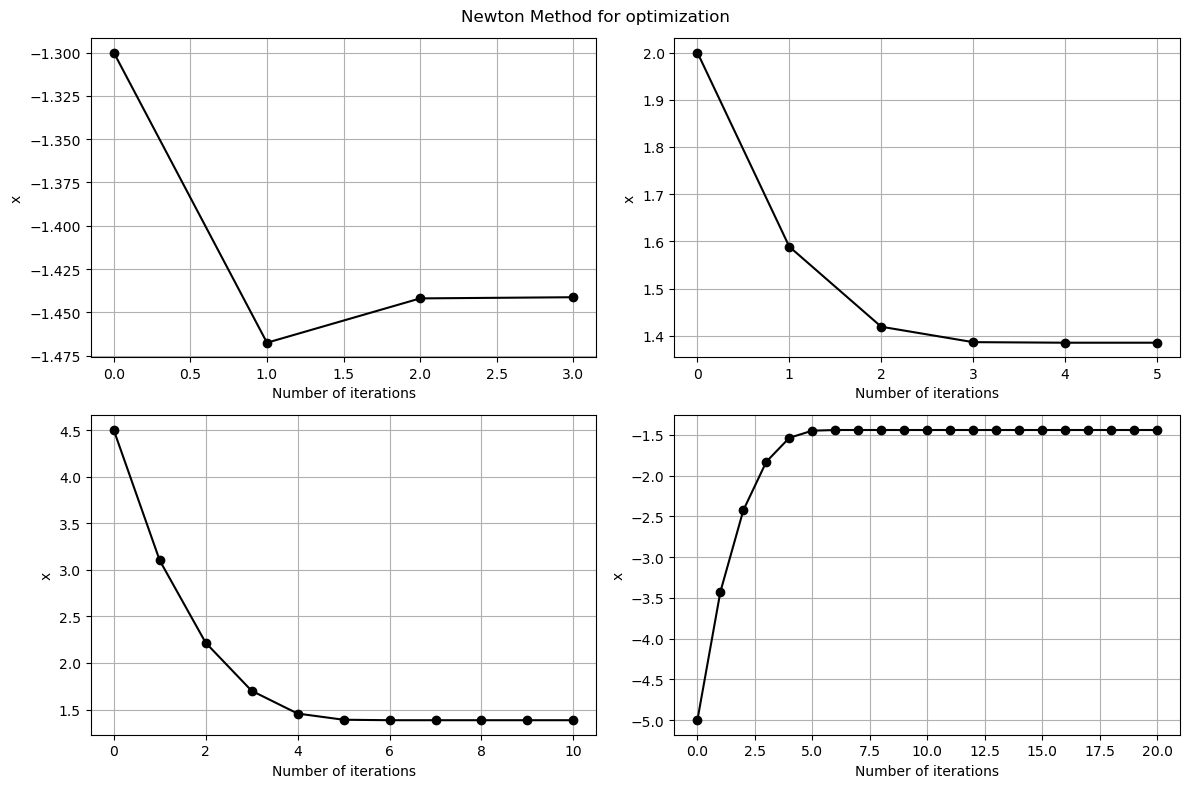

In [21]:
#Optimizing 
fig , ax = plt.subplots ( 2,2 , figsize = ( 12,8 ) ) 
ax = ax.flatten() 

num , x , var  = [ 3,5,10,20 ] , [-1.3, 2, 4.5 , -5 ]  , [] 
for i in range ( 4 ) : 
    
    X = newton_optimize ( iter_num = num[i]  , xo = x[i]  ) 
    var.append(X[-1]) 
    ax[i].plot ( range(len(X)) , X , color= 'black' , marker = 'o' ) 
    ax[i].grid ( True ) 
    ax[i].set_xlabel ('Number of iterations') 
    ax[i].set_ylabel ( 'x')
plt.suptitle( 'Newton Method for optimization') 
plt.tight_layout() 

plt.show() 

In [22]:
val = [ f_prime( var[i] )  for i in range(len(var))  ] 
val

[-7.89565157277572e-06,
 4.1484815582748524e-11,
 1.5543122344752192e-15,
 -2.220446049250313e-16]

so var are the roots of first order and that is exremmum for the function

In [23]:
values = [ f( var[i] )  for i in range(len(var))  ] 
values

[-9.634595485750676,
 -8.377759748784804,
 -8.377759748784804,
 -9.634595485752518]

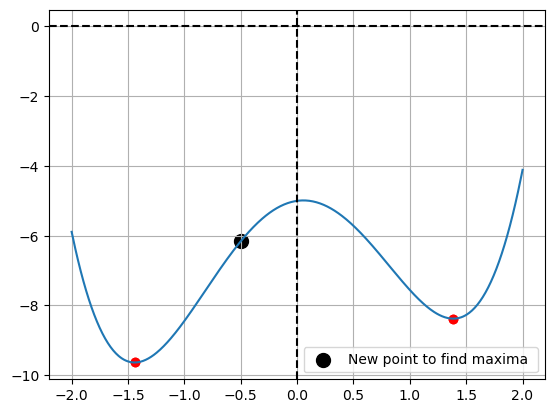

In [24]:

x = np.linspace ( -2,2 , 500 )
fx = f(x) 
plt.figure() 
plt.plot( x,fx)
plt.axhline ( 0 , color = 'black' , linestyle = '--' ) 
plt.axvline ( 0 , color = 'black' , linestyle = '--' ) 
plt.scatter ( -0.5 , f(-0.5) , color = 'black' , s= 100 , label = 'New point to find maxima ' ) 
plt.legend()  
plt.grid ( True ) 
plt.scatter( var , values , color ='red'  ) 
plt.show() 

Not a convex function so it found two minimum of the functions

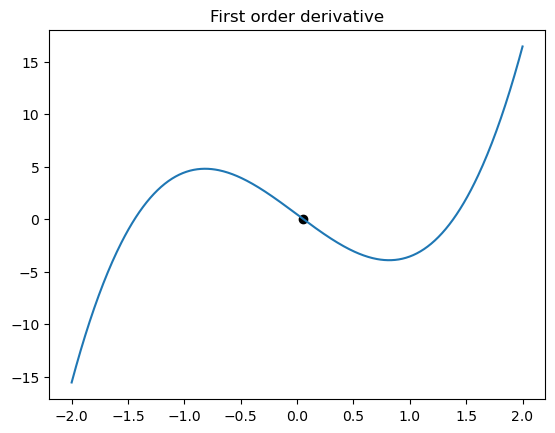

In [25]:
plt.figure () 
plt.plot ( x , f_prime(x) ) 
plt.title( 'First order derivative') 

X = newton_optimize( 12  , xo = -0.5 ) 
plt.scatter ( X[-1] , f_prime( X[-1] ) , color = 'black' ) 
plt.show ( )

Since the functin around that point is decreasing or from positive to negative slope which means it is a maxima , and also the sign of second order also tells information

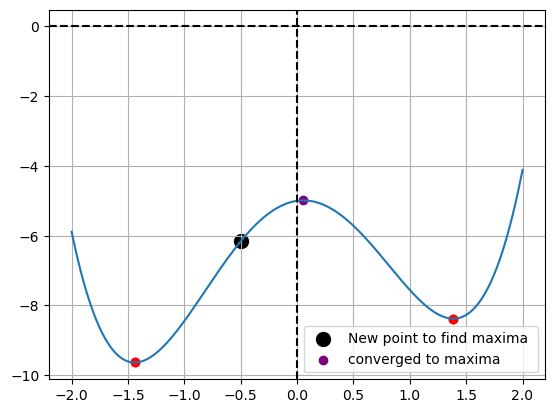

In [26]:
#After convergence 
plt.figure() 
plt.plot( x,fx)
plt.axhline ( 0 , color = 'black' , linestyle = '--' ) 
plt.axvline ( 0 , color = 'black' , linestyle = '--' ) 
plt.scatter ( -0.5 , f(-0.5) , color = 'black' , s= 100 , label = 'New point to find maxima ' ) 

plt.scatter ( X[-1] , f( X[-1] ) , color = 'purple' , label = 'converged to maxima'  ) 
plt.legend()  
plt.grid ( True ) 
plt.scatter( var , values , color ='red'  ) 
plt.show() 

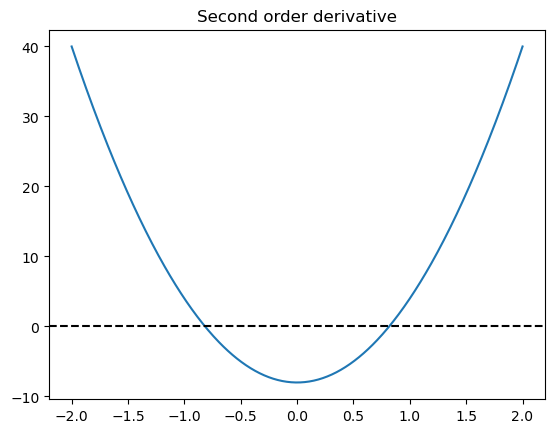

In [27]:
plt.figure ( ) 
plt.title('Second order derivative' ) 
plt.plot ( x, f_2_prime( x ) ) 
plt.axhline ( 0 , color ='black' , linestyle ='dashed'  ) 
plt.show() 


Because at that point second order derivative is decreasing and its negative , and the first order derivative which is is going from positive to negative indicating maxima 

# Gradient Descent

Newton method for approimation is based on taylor series which finds the roots of a function ( first order for optimization) which means finding the critical points of a function, Gradient descent subtracts the slope at xo from xo to move against the direction of ascent and moves tilll it finds minimum where the slope is zero

In [28]:
def f ( x ) : 
    return -2*x**2 + 0.5*x**3 + 0.3*x**4

def f_1 ( x) : 
    return -4*x + (3*0.5)*x**2 + (0.3*4)*x**3

def GS ( learning_rate , iter_num , xo = None ) : 
    x_s = [ ] 
    if xo == None : 
        xo = np.random.choice ( np.linspace ( -4,3, 500) , size = 1 )[0]
    x_s.append( xo ) 
    for _ in range ( iter_num ) : 
        df = f_1( xo) 
        if df == 0 : 
            break 
        xn = xo - learning_rate *df  #Moving against the direction of the gradient
        xo = xn 
        x_s.append(xn) 
    return x_s
    

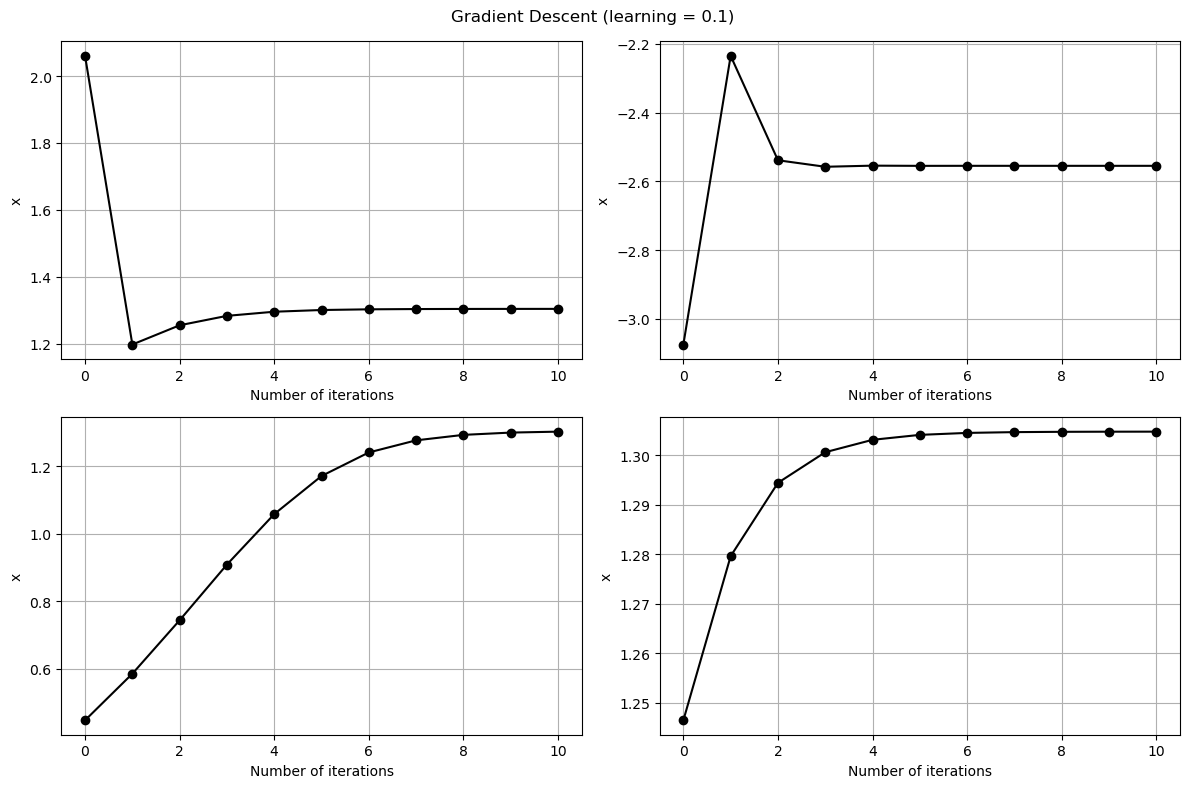

In [29]:
fig , ax = plt.subplots ( 2,2 , figsize = ( 12,8 ) ) 
ax = ax.flatten() 
var = [ ] 
for i in range ( 4 ) : 
    
    X = GS ( 0.1 , 10 ) 
    var.append(X[-1]) 
    ax[i].plot ( range(len(X)) , X , color= 'black' , marker = 'o' ) 
    ax[i].grid ( True ) 
    ax[i].set_xlabel ('Number of iterations') 
    ax[i].set_ylabel ( 'x')
plt.suptitle( 'Gradient Descent (learning = 0.1) ') 
plt.tight_layout() 

plt.show() 

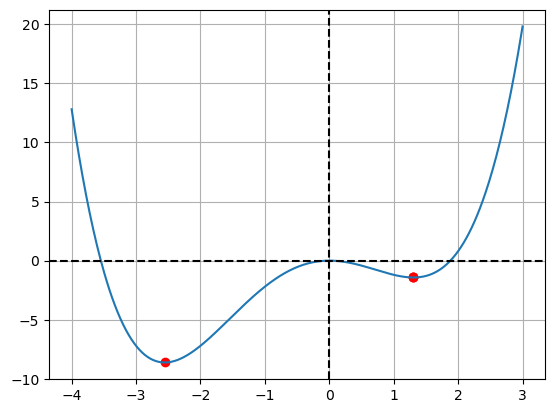

In [30]:
x = np.linspace ( -4,3, 500) 
plt.figure() 
plt.plot ( x , f(x) ) 
plt.axhline ( 0 , color = 'black' , linestyle = '--' ) 
plt.axvline ( 0 , color = 'black' , linestyle = '--' ) 
plt.scatter( var , [ f(var[i]) for i in range(len(var)) ] , color = 'red' ) 
plt.grid() 
plt.show() 

In [31]:
import pandas as pd 

X = GS ( 0.12, 10 ) 
values = [ f(X[i]) for i in range( len( X ) ) ] 



In [32]:
arr = np.column_stack( [X,values] ) 
df = pd.DataFrame ( arr, columns= [ 'xn' , 'f(xn)' ] ) 
df

,xn,f(xn)
0,-2.036072,-7.355765
1,-2.544129,-8.610404
2,-2.559114,-8.610957
3,-2.552909,-8.611049
4,-2.555528,-8.611066
5,-2.554431,-8.611069
6,-2.554892,-8.611069
7,-2.554699,-8.611069
8,-2.554780,-8.611069
9,-2.554746,-8.611069


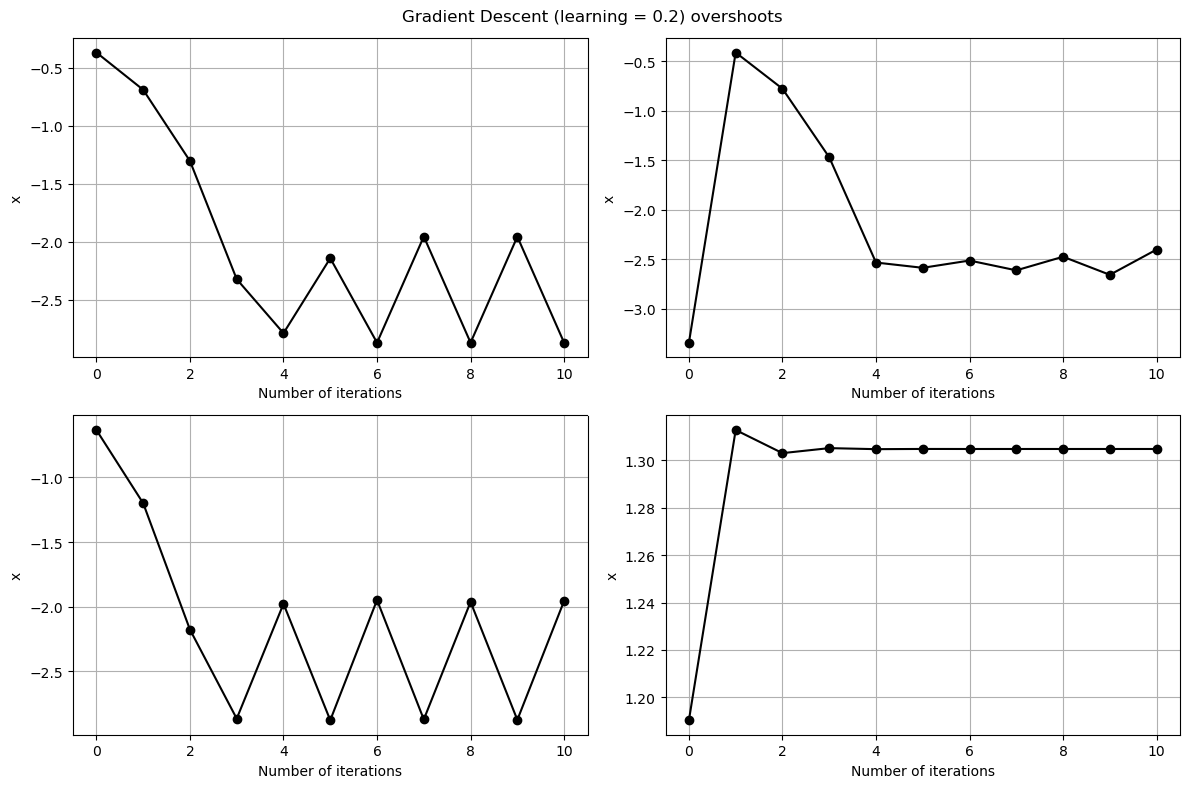

In [33]:
fig , ax = plt.subplots ( 2,2 , figsize = ( 12,8 ) ) 
ax = ax.flatten() 
var = [ ] 
for i in range ( 4 ) : 
    
    X = GS ( 0.2 , 10 ) 
    var.append(X[-1]) 
    ax[i].plot ( range(len(X)) , X , color= 'black' , marker = 'o' ) 
    ax[i].grid ( True ) 
    ax[i].set_xlabel ('Number of iterations') 
    ax[i].set_ylabel ( 'x')
plt.suptitle( 'Gradient Descent (learning = 0.2) overshoots ') 
plt.tight_layout() 

plt.show() 

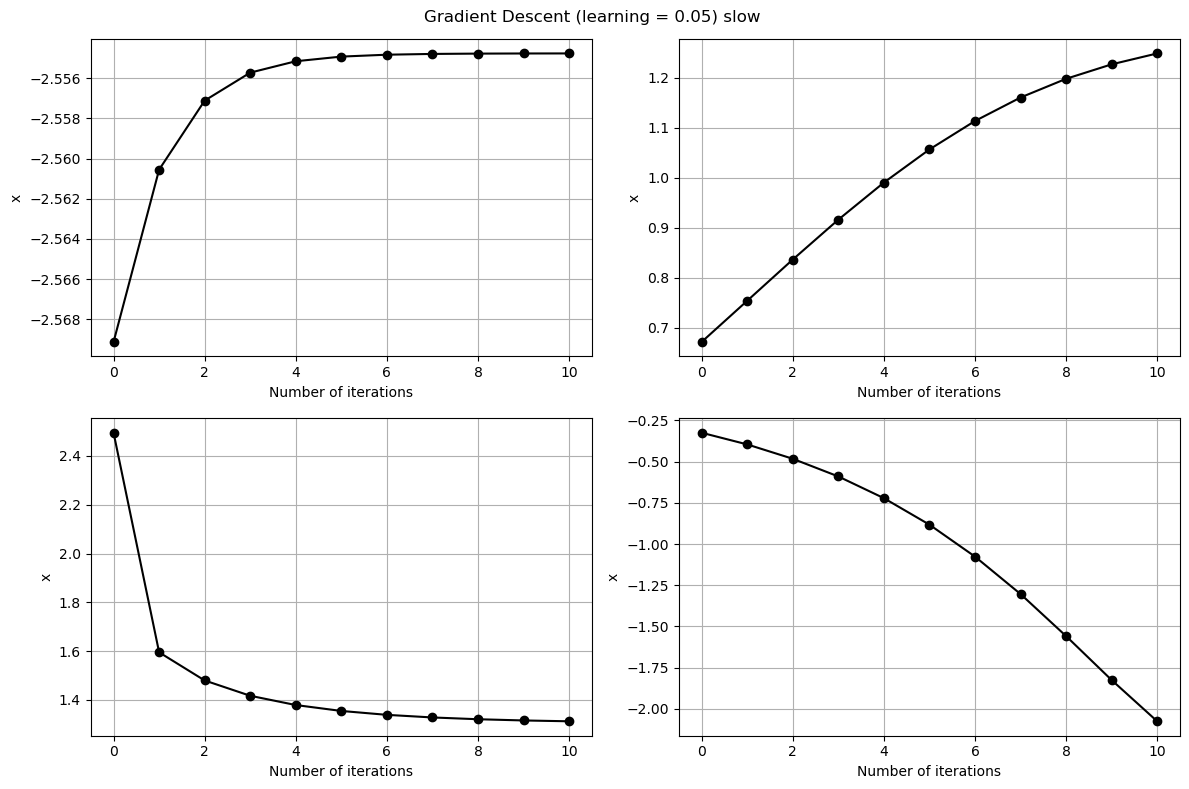

In [34]:
fig , ax = plt.subplots ( 2,2 , figsize = ( 12,8 ) ) 
ax = ax.flatten() 
var = [ ] 
for i in range ( 4 ) : 
    
    X = GS ( 0.05 , 10 ) 
    var.append(X[-1]) 
    ax[i].plot ( range(len(X)) , X , color= 'black' , marker = 'o' ) 
    ax[i].grid ( True ) 
    ax[i].set_xlabel ('Number of iterations') 
    ax[i].set_ylabel ( 'x')
plt.suptitle( 'Gradient Descent (learning = 0.05) slow ') 
plt.tight_layout() 

plt.show() 

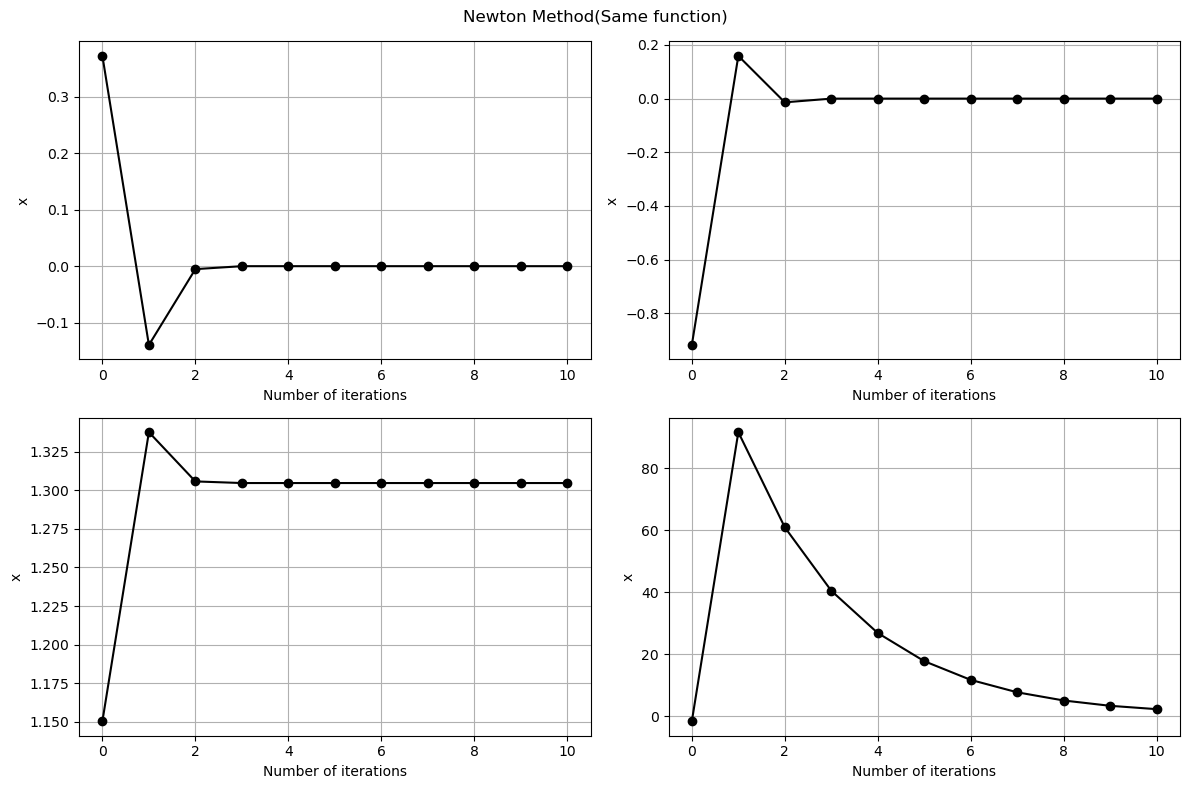

In [35]:
#newton method converges way too fast 

def f(x) : 
    return -2*x**2 + 0.5*x**3 + 0.3*x**4 

def f_prime ( x ) : 
    return  -4*x + (3*0.5)*x**2 + (0.3*4)*x**3

def f_2_prime ( x )  : 
    return -4 +(3*0.5*2)*x +(0.3*4*3)*x**2

def newton_optimize ( iter_num , xo = None ) : 
    x_s = [ ] 
    if xo == None :
        xo = np.random.choice ( np.linspace ( -2,2 , 500 ) , size = 1 ) 
    x_s.append(xo ) 

    for i in range ( iter_num ) : 
        f_x = f_prime(xo ) 
        f_xx = f_2_prime( xo ) 
        if f_xx == 0 : 
            break
        xn = xo - ( f_x / f_xx ) 
        x_s.append( xn ) 
        xo = xn

    return x_s 


fig , ax = plt.subplots ( 2,2 , figsize = ( 12,8 ) ) 
ax = ax.flatten() 
for i in range ( 4 ) : 
    
    X = newton_optimize (10  ) 
    ax[i].plot ( range(len(X)) , X , color= 'black' , marker = 'o' ) 
    ax[i].grid ( True ) 
    ax[i].set_xlabel ('Number of iterations') 
    ax[i].set_ylabel ( 'x')
plt.suptitle( 'Newton Method(Same function)') 
plt.tight_layout() 

plt.show() 

It calculated both maxima tho

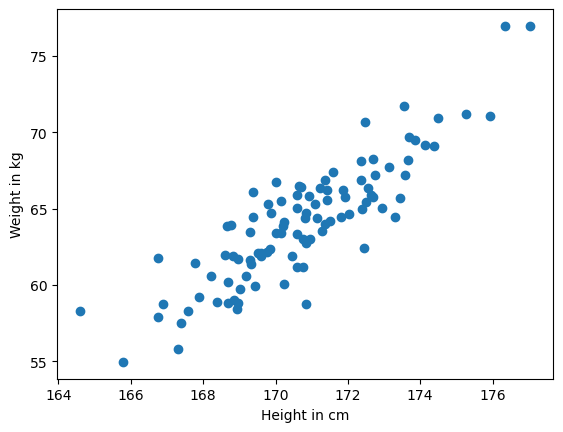

In [36]:
data = np.random.multivariate_normal( [ 171 , 65 ] , 
                                      [ 
                                          [ 2.5**2 , 10 ] ,
                                          [ 10 ,  4.5**2 ] 
                                      ] , 
                                      size = 100 
                                    ) 

plt.figure() 
plt.scatter  ( data[:,0] , data[:,1] ) 
plt.xlabel( 'Height in cm') 
plt.ylabel( 'Weight in kg') 
plt.show( )

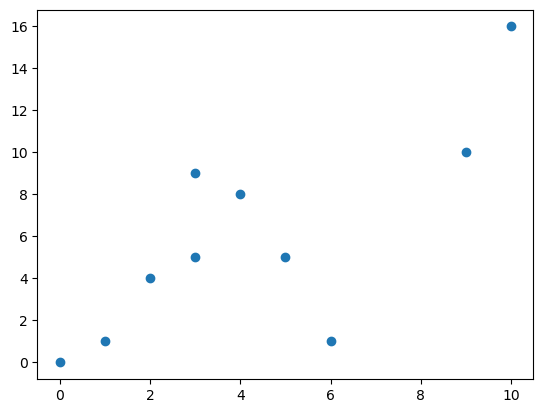

In [37]:
x = np.array (  [ 0,1,2,3,5,9,10,3,4,6 ] ) 

y = np.array ( [0,1,4,5,5,10,16,9,8,1] ) 

plt.figure( )  
plt.scatter ( x, y ) 
plt.show() 

In [38]:
N = len(y ) 

def cost ( m ) :                                   #Mean Squared errors
    return np.sum( ( y - m*x )**2 ) / N  

cost (2 ) , cost (2.3) 

(np.float64(23.7), np.float64(38.108999999999995))

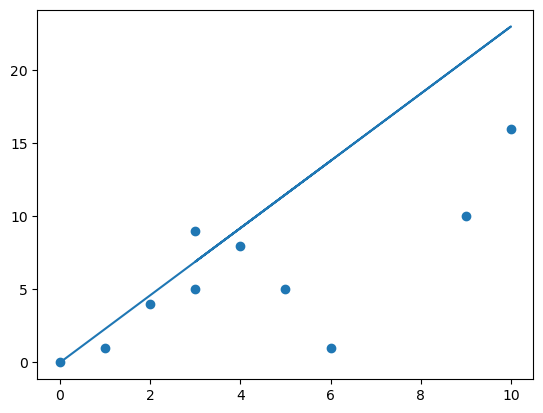

In [39]:
y_predict =2.3*x 
plt.figure( )  
plt.scatter ( x, y ) 
plt.plot( x , 2.3*x ) 
plt.show() 
 

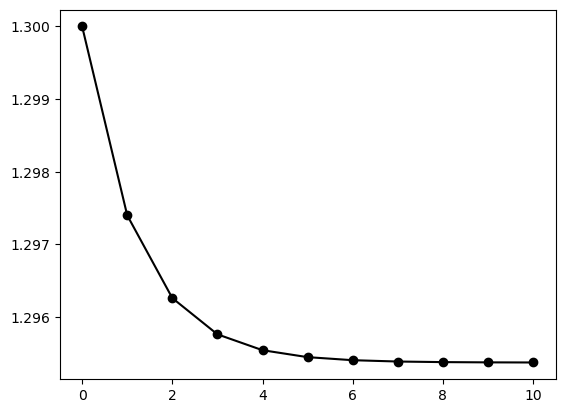

In [40]:
def cost_2 ( m ) :  
    return (-2/N) * np.sum( x*(y-m*x) ) 

def GRD ( mo , iter_num , learning) : 
    ms = [ ]
    ms.append(mo) 
    for _ in range( iter_num) :
        mn = mo - learning* cost_2(mo) 
        ms.append(mn ) 
        mo = mn
    return ms 


X = GRD ( 1.3 , 10 , 0.01)
plt.figure( ) 
plt.plot( range(len(X)) , X , color ='black' , marker = 'o') 
plt.show()

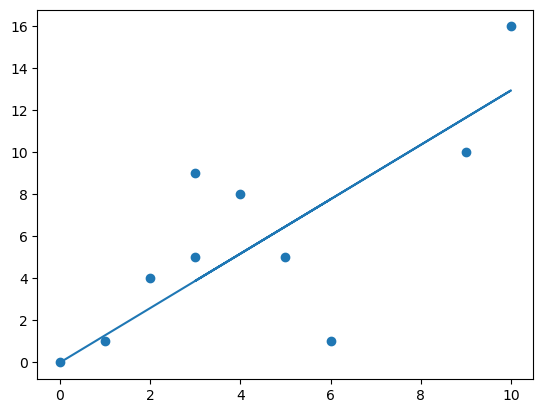

In [41]:
plt.figure( )  
plt.scatter ( x, y ) 
plt.plot( x , X[-1]*x ) 
plt.show() 


Here we have the cost function with one parameter if we expand the cost function it will quadratic hyperbola so with m = 1.3 the cost function is maximum reduced and since it is convex it is its global minimum 

In [42]:
X[-1] 

np.float64(1.2953748676843406)

In [43]:
cost( X[-1] ) 

np.float64(9.748398576553068)

In [44]:
np.round(cost_2 ( X[-1] ) ,2 ) 

np.float64(0.0)

AT this m = 1.2 the cost function reaches its global minimum  and also the the change of cost function by small m ( derivative ) is zero , so this is linear regresssion with one parameter 

In [45]:
plt.close('all') 

# Three dimension

In [46]:
def f ( x ) : 
    return -2*x**2 + 0.5*x**3 + 0.3*x**4

def f_1 ( x) : 
    return -4*x + (3*0.5)*x**2 + (0.3*4)*x**3

def GS ( learning_rate , iter_num , xo = None ) : 
    x_s = [ ] 
    if xo == None : 
        xo = np.random.choice ( np.linspace ( -4,3, 500) , size = 1 )[0]
    x_s.append( xo ) 
    for _ in range ( iter_num ) : 
        df = f_1( xo) 
        if df == 0 : 
            break 
        xn = xo - learning_rate *df  #Moving against the direction of the gradient
        xo = xn 
        x_s.append(xn) 
    return x_s
    

In [47]:
import sympy as sp 
x, y = sp.symbols('x y')

centers = [(2, 2), (-2, 2), (-2, -2), (2, -2)]
gaussians = sum(3 * sp.exp(-((x - cx)**2 + (y - cy)**2)) for cx, cy in centers)
exp = 0.05 * (x**2 + y**2) - gaussians
sp_dx = sp.diff(exp, x)
sp_dy = sp.diff(exp, y)

f = sp.lambdify((x, y), exp, 'numpy')
fx = sp.lambdify((x, y), sp_dx, 'numpy')
fy = sp.lambdify((x, y), sp_dy, 'numpy')

def grad_f(x_val, y_val):
    return np.array([fx(x_val, y_val), fy(x_val, y_val)])


In [48]:
exp 

0.05*x**2 + 0.05*y**2 - 3*exp(-(x - 2)**2 - (y - 2)**2) - 3*exp(-(x - 2)**2 - (y + 2)**2) - 3*exp(-(x + 2)**2 - (y - 2)**2) - 3*exp(-(x + 2)**2 - (y + 2)**2)

In [49]:
sp_dx

0.1*x - 3*(4 - 2*x)*exp(-(x - 2)**2 - (y - 2)**2) - 3*(4 - 2*x)*exp(-(x - 2)**2 - (y + 2)**2) - 3*(-2*x - 4)*exp(-(x + 2)**2 - (y - 2)**2) - 3*(-2*x - 4)*exp(-(x + 2)**2 - (y + 2)**2)

In [50]:
sp_dy

0.1*y - 3*(4 - 2*y)*exp(-(x - 2)**2 - (y - 2)**2) - 3*(4 - 2*y)*exp(-(x + 2)**2 - (y - 2)**2) - 3*(-2*y - 4)*exp(-(x - 2)**2 - (y + 2)**2) - 3*(-2*y - 4)*exp(-(x + 2)**2 - (y + 2)**2)

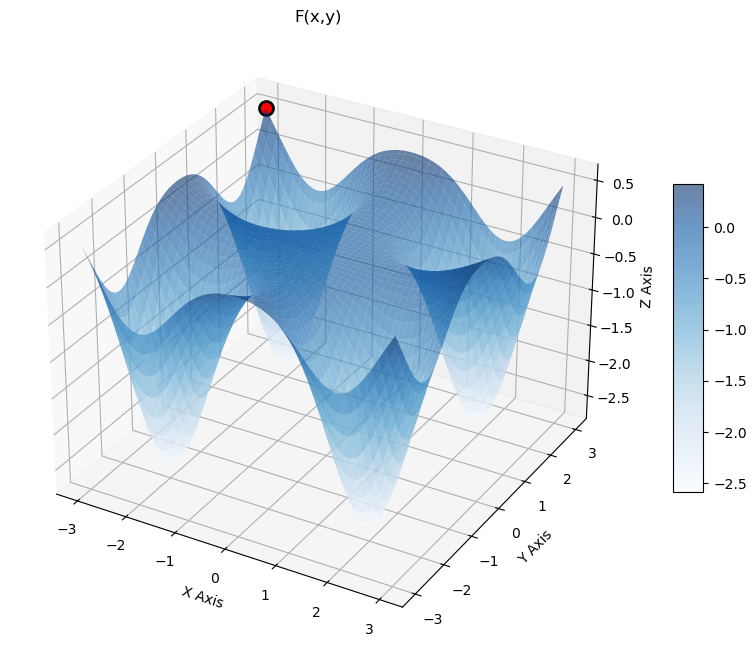

In [51]:
%matplotlib inline
x = np.linspace(-3, 3, 100) 
y = np.linspace(-3, 3, 100)  
X, Y = np.meshgrid(x, y) 

data_points = f(X, Y) 

fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(projection='3d')

surf = ax.plot_surface(X, Y, data_points, cmap='Blues', alpha=0.6, edgecolor='none')


ax.scatter(
    -3, 3, f(-3, 3), 
    s=100, 
    color='red', 
    marker='o', 
    edgecolors='black', 
    linewidth=2, 
    depthshade=False  
)

ax.set_xlabel('X Axis')
ax.set_ylabel('Y Axis')
ax.set_zlabel('Z Axis')
ax.set_title('F(x,y)')
fig.colorbar(surf, shrink=0.5, aspect=10)
plt.show()

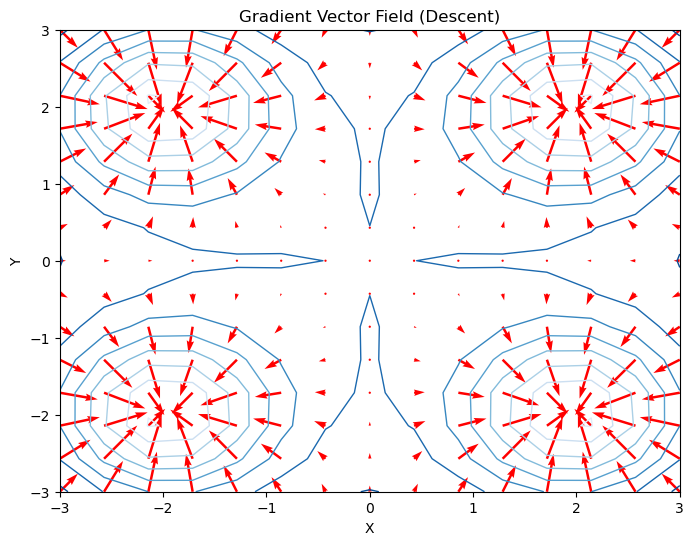

In [52]:
x = np.linspace(-3, 3, 15)
y = np.linspace(-3, 3, 15)
X, Y = np.meshgrid(x, y)


Z = f(X, Y)
U = fx(X, Y)  
V = fy(X, Y)  

fig, ax = plt.subplots(figsize=(8, 6))

ax.quiver(X, Y, -U, -V, color='red', alpha=1)
ax.contour(X, Y, Z, levels=8, cmap='Blues', linewidths=1)
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_title('Gradient Vector Field (Descent)')
plt.show()


In [53]:
def GD(learning, iter_num, xo=None, yo=None):
    if xo is None:
        xo = np.random.uniform(-50, 50)
    if yo is None:
        yo = np.random.uniform(-50, 50)
    
    point = np.array([xo, yo], dtype=float)
    history = [point.copy()]

    for _ in range(iter_num):
        grad = grad_f(point[0], point[1]) 
        point -= learning * grad           
        history.append(point.copy())
        
    history = np.array(history)
    return history[:, 0], history[:, 1]    

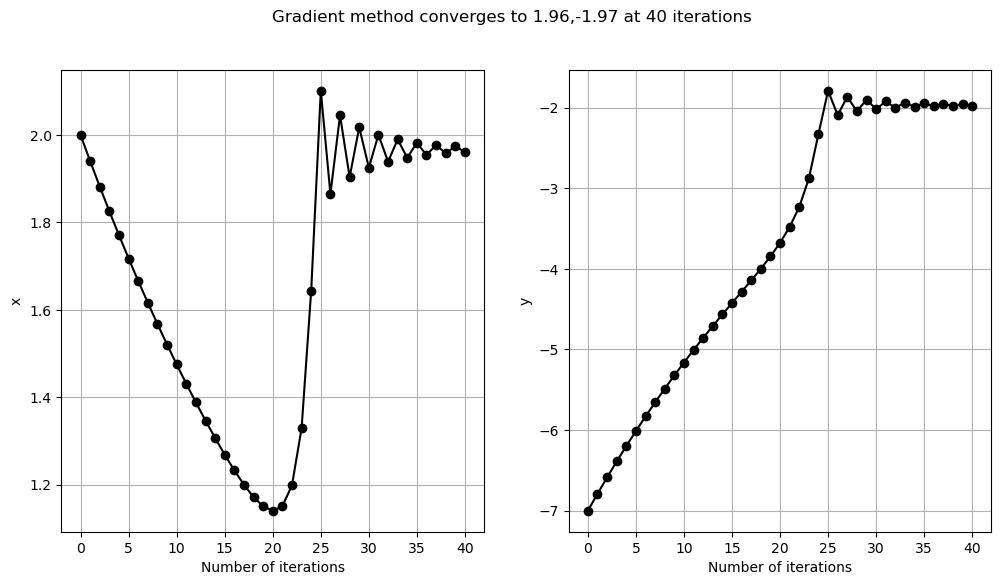

In [54]:
X,Y = GD ( 0.3 ,40, xo = 2, yo = -7) 
fig , ax = plt.subplots(1,2, figsize = (12,6) )
ax[0].plot ( range(len(X)) , X , color= 'black' , marker = 'o' ) 
ax[0].grid ( True ) 
ax[0].set_xlabel ('Number of iterations') 
ax[0].set_ylabel ( 'x')

ax[1].plot ( range(len(Y)) , Y , color= 'black' , marker = 'o' ) 
ax[1].grid ( True ) 
ax[1].set_xlabel ('Number of iterations') 
ax[1].set_ylabel ( 'y')
plt.suptitle( f'Gradient method converges to {X[-1]:.2f},{Y[-1]:.2f} at 40 iterations') 
plt.show( )

In [55]:
np.round(grad_f( X[-1] , Y[-1] )) , f(X[-1], Y[-1]) 

(array([-0., -0.]), np.float64(-2.6062874291168923))

# Linear Regression 

First by gradient descent

In [56]:

def cost(x, y, m, b): 
    x, y = np.asarray(x), np.asarray(y)
    return np.mean((y - (m * x + b)) ** 2)

def gradient(x, y, m, b): 
    x, y = np.asarray(x), np.asarray(y)
    N = len(x)
    error = y - (m * x + b)
    dm = (-2 / N) * np.sum(error * x)
    db = (-2 / N) * np.sum(error)
    return np.array([dm, db])


def gradient_descent (  x,y ,learning , iter_num , mo= None , bo =None ) :
    if mo is None : 
        mo = np.random.uniform(-50, 50)
    if bo is None : 
        bo = np.random.uniform(-50, 50)

    parameters  = np.array ( [ mo , bo ] , dtype = 'float') 

    track = [parameters.copy() ] 

    for _ in range( iter_num ) : 

        grad = gradient(x, y, parameters[0], parameters[1])
        parameters = parameters - learning*grad

        track.append( parameters.copy() ) 
    
    
    track = np.array(track)
    return track[:, 0], track[:, 1]
    
    

In [57]:
data = np.random.multivariate_normal( [ 171 , 65 ] , 
                                      [ 
                                          [ 2.5**2 , 10 ] ,
                                          [ 10 ,  4.5**2 ] 
                                      ] , 
                                      size = (100,) 
)

#Scaling the independent variable z score
data_x = (data[:, 0] - np.mean(data[:, 0])) / np.std(data[:, 0])

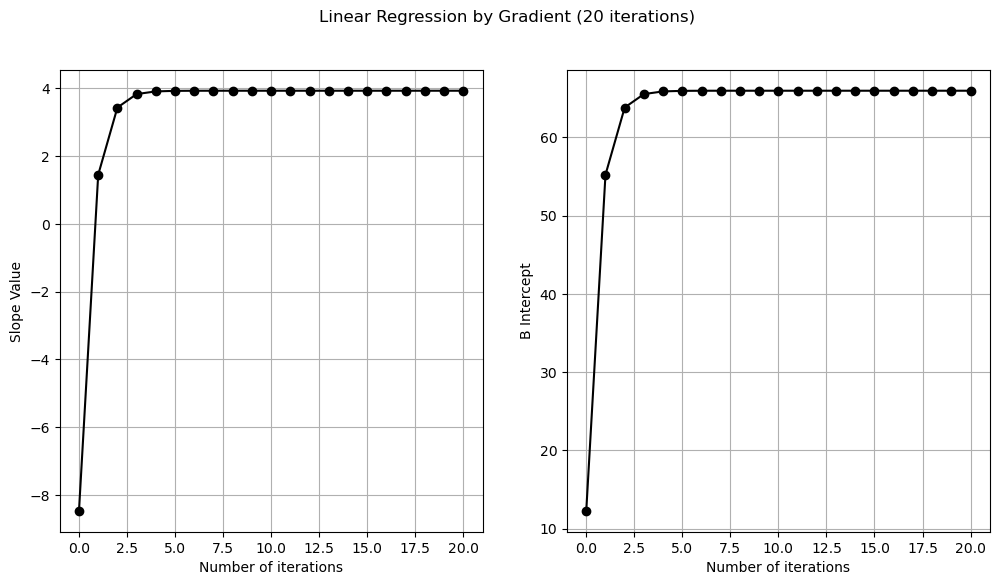

In [58]:
M, B = gradient_descent(x=data_x, y=data[:,1], learning=0.4, iter_num=20)

fig, ax = plt.subplots(1, 2, figsize=(12, 6))

ax[0].plot(range(len(M)), M, color='black', marker='o') 
ax[0].grid(True) 
ax[0].set_xlabel('Number of iterations') 
ax[0].set_ylabel('Slope Value')


ax[1].plot(range(len(B)), B, color='black', marker='o') 
ax[1].grid(True) 
ax[1].set_xlabel('Number of iterations') 
ax[1].set_ylabel('B Intercept')
plt.suptitle('Linear Regression by Gradient (20 iterations) ') 
plt.show()


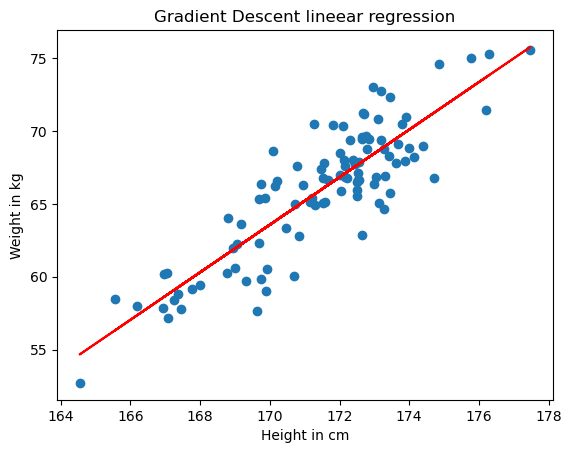

In [59]:
model = M[-1]*data_x + B[-1]
plt.figure() 
plt.scatter  ( data[:,0] , data[:,1] ) 
plt.plot( data[:,0] , model , color = 'red'  ) 
plt.xlabel( 'Height in cm') 
plt.ylabel( 'Weight in kg') 
plt.title('Gradient Descent lineear regression')
plt.show( )

In [60]:
r2 = 1 - (np.var(data[:, 1] - model) / np.var(data[:, 1]))
print(f"R² Score: {r2:.4f}")


R² Score: 0.7543


In [61]:
cost(data_x , data[:,1] , M[-1], B[-1] ) 

np.float64(5.0260524291043485)

In [62]:
gradient(data_x , data[:,1] , M[-1], B[-1]) 

array([-2.60594879e-13, -1.12507337e-12])

Now by newton method

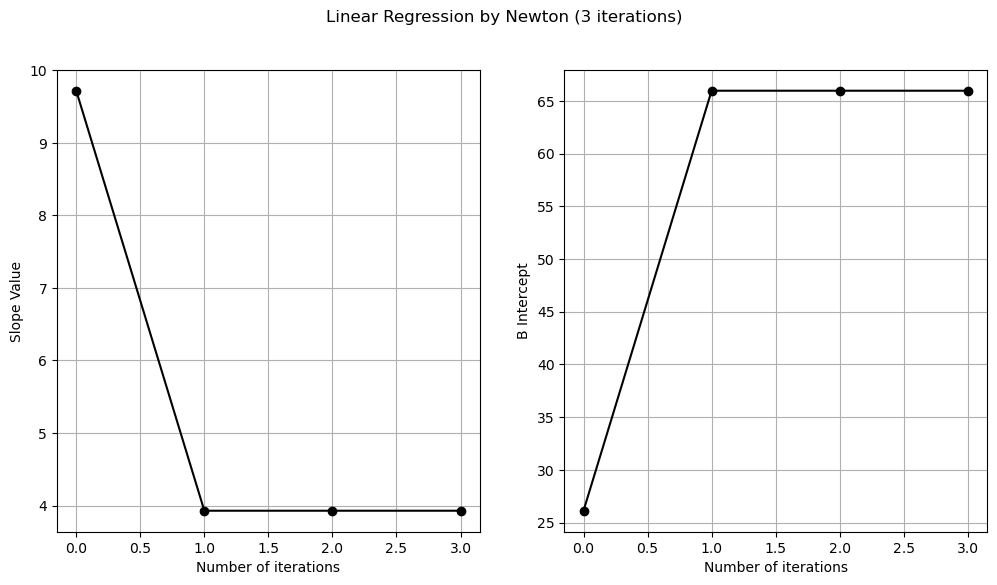

In [63]:
def cost(x, y, m, b): 
    x, y = np.asarray(x), np.asarray(y)
    return np.mean((y - (m * x + b)) ** 2)

def gradient(x, y, m, b): 
    x, y = np.asarray(x), np.asarray(y)
    N = len(x)
    error = y - (m * x + b)
    dm = (-2 / N) * np.sum(error * x)
    db = (-2 / N) * np.sum(error)
    return np.array([dm, db])

def hessian(x): 
    cost_mm = np.mean(2 * (x**2)) 
    cost_bb = 2.0  
    cost_mb = np.mean(2 * x) 

    hess = np.array([
        [cost_mm, cost_mb],
        [cost_mb, cost_bb] 
    ])
    return hess



def newton_method(x, y, iter_num=5, mo=None, bo=None):
    if mo is None: mo = np.random.uniform(-50, 50)
    if bo is None: bo = np.random.uniform(-50, 50)
    
    parameters = np.array([mo, bo], dtype=float)
    
    H_inv = np.linalg.inv(hessian(x))
    
    track = [parameters.copy()]
    for _ in range(iter_num):
        grad = gradient(x, y, parameters[0], parameters[1])
        parameters -= H_inv @ grad
        track.append(parameters.copy())
        
    track = np.array(track)
    return track[:, 0], track[:, 1]


M, B = newton_method(data_x, y=data[:,1] , iter_num = 3)

fig, ax = plt.subplots(1, 2, figsize=(12, 6))
plt.suptitle('Linear Regression by Newton (3 iterations) ')
ax[0].plot(range(len(M)), M, color='black', marker='o') 
ax[0].grid(True) 
ax[0].set_xlabel('Number of iterations') 
ax[0].set_ylabel('Slope Value')


ax[1].plot(range(len(B)), B, color='black', marker='o') 
ax[1].grid(True) 
ax[1].set_xlabel('Number of iterations') 
ax[1].set_ylabel('B Intercept')
 
plt.show()


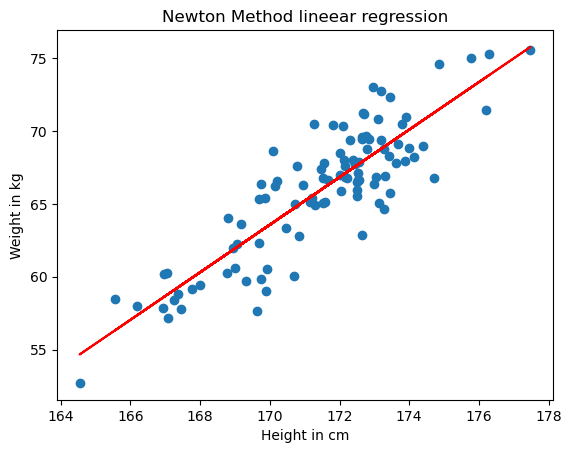

In [64]:
model = M[-1]*data_x + B[-1]
plt.figure() 
plt.scatter  ( data[:,0] , data[:,1] ) 
plt.plot( data[:,0] , model , color = 'red' ) 
plt.xlabel( 'Height in cm') 
plt.ylabel( 'Weight in kg') 
plt.title('Newton Method lineear regression')
plt.show( )

In [65]:
hessian( data_x ) 

array([[2.00000000e+00, 8.18678458e-15],
       [8.18678458e-15, 2.00000000e+00]])

In [66]:
r2 = 1 - (np.var(data[:, 1] - model) / np.var(data[:, 1]))
print(f"R² Score: {r2:.4f}")


R² Score: 0.7543


# Stochastic Gradient Descent

In [67]:
def cost(x, y, m, b):
    return (y - (m * x + b)) ** 2

def gradient(x, y, m, b):
    error = y - (m * x + b)
    dm = -2 * error * x
    db = -2 * error
    return np.array([dm, db])


def sgd(x, y, learning=0.01, epochs=2, mo=None, bo=None):
    if mo is None: 
        mo = 0.0
    if bo is None: 
        bo = 1.0

    ms, bs, cost_h, average_loss = [], [], [], []
    ms.append(mo) 
    bs.append(bo)

    x = np.asarray(x)
    y = np.asarray(y)

    for epoch in range(epochs): 

        indices = np.random.permutation(len(x))
        x_shuffled = x[indices]
        y_shuffled = y[indices]

        for xo, yo in zip(x_shuffled, y_shuffled): 
            loss = cost(xo, yo, mo, bo)
            grad = gradient(xo, yo, mo, bo) 


            mo = mo - learning * grad[0] 
            bo = bo - learning * grad[1] 

            ms.append(mo) 
            bs.append(bo) 
            cost_h.append(loss) 


        average_loss.append(np.mean(cost_h)) 
        cost_h = []

    return ms, bs, average_loss

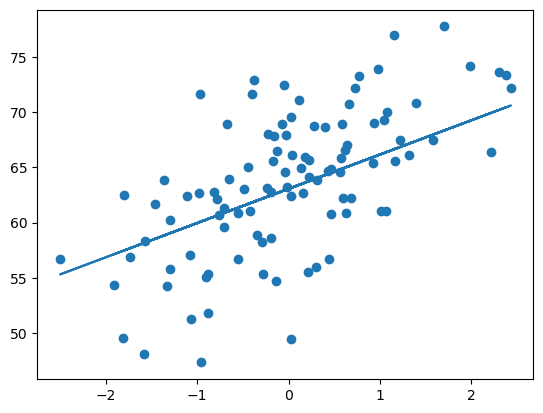

(np.float64(3.1064271030128934),
 np.float64(63.058570034114744),
 np.float64(29.19937356557578))

In [68]:
data = np.random.multivariate_normal( [ 171 , 65 ] , 
                                      [ 
                                          [ 2.5**2 , 10 ] ,
                                          [ 10 ,  6.5**2 ] 
                                      ] , 
                                      size = (100,) 
)

#Scaling the independent variable z score
data_x = (data[:, 0] - np.mean(data[:, 0])) / np.std(data[:, 0])


m,b,loss = sgd( data_x, data[:,1], epochs= 25, learning=0.05, mo = 24, bo = -24)


plt.figure() 
plt.plot( data_x, m[-1]*data_x + b[-1] ) 
plt.scatter( data_x , data[:,1] ) 
plt.show() 


m[-1] , b[-1] , loss[-1]

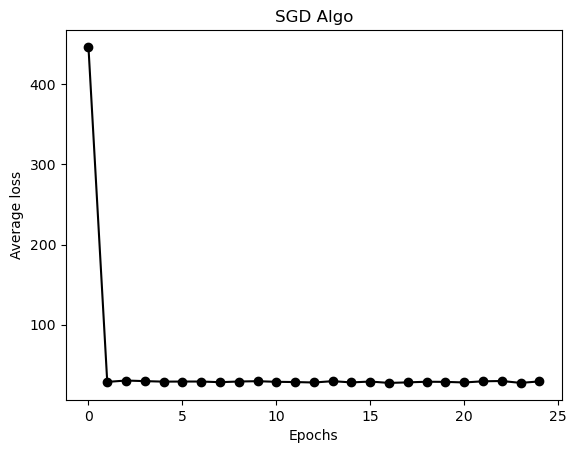

In [69]:
plt.figure() 
plt.title('SGD Algo') 
plt.plot(range(len(loss)) , loss , color = 'black' , marker = 'o' ) 
plt.xlabel('Epochs') 
plt.ylabel('Average loss')
plt.show( )


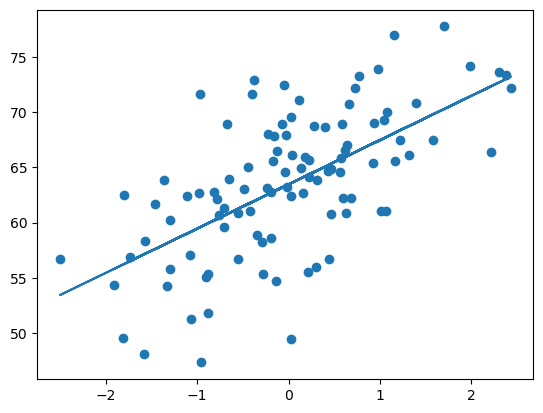

(np.float64(4.014508026743233),
 np.float64(63.46070800239176),
 np.float64(25.68225092629226))

In [70]:
#Computing loss by gradient descent
def cost(x, y, m, b): 
    x, y = np.asarray(x), np.asarray(y)
    return np.mean((y - (m * x + b)) ** 2)

def gradient(x, y, m, b): 
    x, y = np.asarray(x), np.asarray(y)
    N = len(x)
    error = y - (m * x + b)
    dm = (-2 / N) * np.sum(error * x)
    db = (-2 / N) * np.sum(error)
    return np.array([dm, db])

def gradient_descent(x, y, learning, iter_num, mo=None, bo=None):
    if mo is None: 
        mo = np.random.uniform(-50, 50)
    if bo is None: 
        bo = np.random.uniform(-50, 50)

    parameters = np.array([mo, bo], dtype='float') 

    track = [parameters.copy()]
    loss_history = []  

    for _ in range(iter_num): 
        
        current_loss = cost(x, y, parameters[0], parameters[1])
        loss_history.append(current_loss)

        
        grad = gradient(x, y, parameters[0], parameters[1])
        parameters = parameters - learning * grad

        
        track.append(parameters.copy()) 
    
    
    final_loss = cost(x, y, parameters[0], parameters[1])
    loss_history.append(final_loss)
    
    track = np.array(track)
    
    return track[:, 0], track[:, 1], np.array(loss_history)


m,b,loss = gradient_descent( data_x, data[:,1], learning=0.05 ,iter_num= 50)


plt.figure() 
plt.plot( data_x, m[-1]*data_x + b[-1] ) 
plt.scatter( data_x , data[:,1] ) 
plt.show() 


m[-1] , b[-1] , loss[-1]

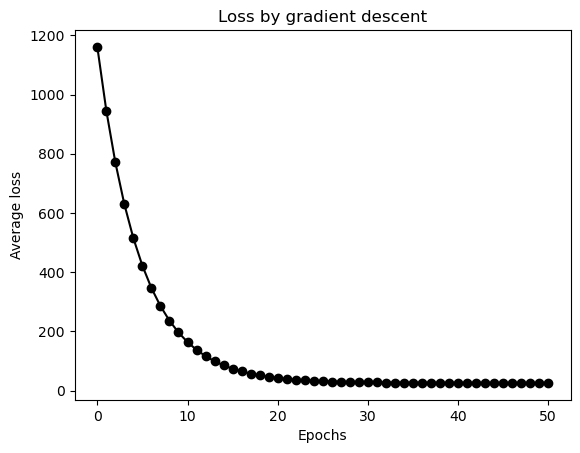

In [71]:
plt.figure() 
plt.title('Loss by gradient descent') 
plt.plot(range(len(loss)) , loss , color = 'black' , marker = 'o' ) 
plt.xlabel('Epochs') 
plt.ylabel('Average loss')
plt.show( )


# Neural network for classification

In [72]:
import pandas as pd
np.random.seed(43)
heights = np.random.uniform(150, 190, 150).round(1)

weights = np.random.uniform(40, 100, 150).round(1)


df = pd.DataFrame({"Height(cm)": heights, "Weight(kg)": weights})


height_m = df["Height(cm)"] / 100
bmi = df["Weight(kg)"] / (height_m**2)


df["Label"] = ((bmi >= 18.5) & (bmi <= 24.9)).astype(int)

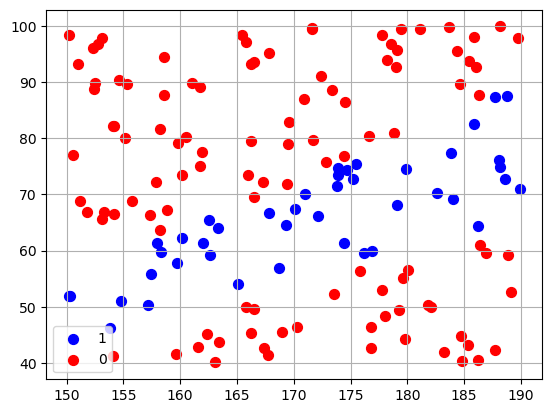

In [73]:
d0 = df[df["Label"] == 0]

d1 = df[df["Label"]==1]

plt.figure() 
plt.scatter(d1.iloc[:,0], d1.iloc[:,1], color = 'blue' , s = 50 , label = '1') 
plt.scatter(d0.iloc[:,0], d0.iloc[:,1], color = 'red' , s = 50 , label = '0') 
plt.legend() 
plt.grid(True) 

plt.show() 

In [74]:
height = df['Height(cm)'].to_numpy() 

weight = df['Weight(kg)'].to_numpy() 
scaled_x = ( height - np.min(height) )/ ( np.max(height) - np.min(height) ) 

scaled_y =  ( weight - np.min(weight) )/ ( np.max(weight) - np.min(weight) ) 
X = np.column_stack((scaled_x, scaled_y))
y = df['Label'].to_numpy().reshape(-1,1) 

In [75]:
height_min, height_max = np.min(height), np.max(height)
weight_min, weight_max = np.min(weight), np.max(weight)

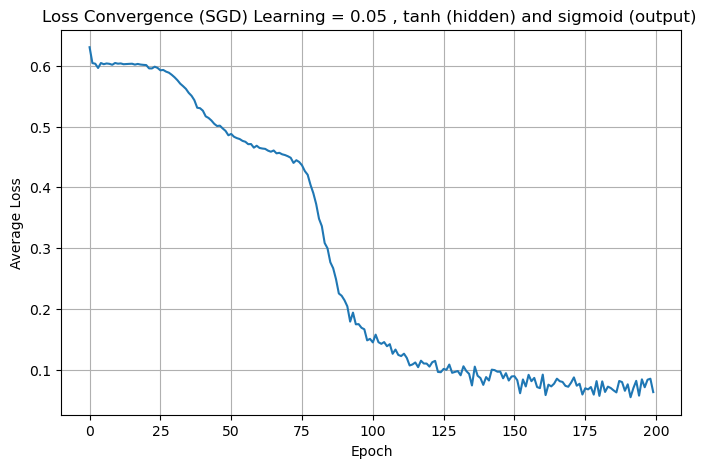

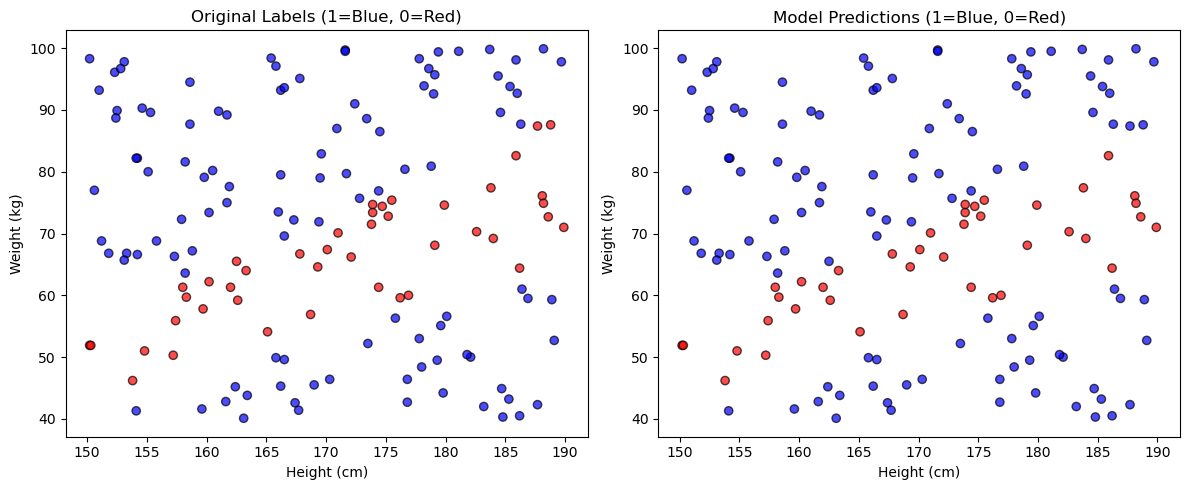

In [76]:
def sigmoid(z):
    return 1 / (1 + np.exp(-np.clip(z, -250, 250)))

def tanh(z):
    return np.tanh(z)

def sigmoid_derivative(a):
    return a * (1 - a)

def tanh_derivative(a):
    return 1 - a**2

def forward(X, W1, b1, W2, b2):
    Z1 = X @ W1 + b1
    H1 = tanh(Z1)
    Z2 = H1 @ W2 + b2
    y_hat = sigmoid(Z2)
    return Z1, H1, Z2, y_hat

def loss(y, y_hat):
    epsilon = 1e-8
    y_hat = np.clip(y_hat, epsilon, 1 - epsilon)
    return -np.mean(y * np.log(y_hat) + (1 - y) * np.log(1 - y_hat))

def backward(X, y, Z1, H1, Z2, y_hat, W2):
    N = X.shape[0]
    dL_dyhat = -(y / y_hat) + ((1 - y) / (1 - y_hat))
    dL_dyhat = np.clip(dL_dyhat, -1e6, 1e6)
    dyhat_dZ2 = sigmoid_derivative(y_hat)
    dL_dZ2 = dL_dyhat * dyhat_dZ2
    dL_dW2 = H1.T @ dL_dZ2 / N
    dL_db2 = np.mean(dL_dZ2, axis=0, keepdims=True)
    dL_dH1 = dL_dZ2 @ W2.T
    dH1_dZ1 = tanh_derivative(H1)
    dL_dZ1 = dL_dH1 * dH1_dZ1
    dL_dW1 = X.T @ dL_dZ1 / N
    dL_db1 = np.mean(dL_dZ1, axis=0, keepdims=True)
    return dL_dW1, dL_db1, dL_dW2, dL_db2

def train_sgd(X, y, epochs=300, learning_rate=0.5):
    N = X.shape[0]
    n_features = X.shape[1]
    n_hidden = 2

    W1 = np.random.randn(n_features, n_hidden) * 0.01
    b1 = np.zeros((1, n_hidden))
    W2 = np.random.randn(n_hidden, 1) * 0.01
    b2 = np.zeros((1, 1))

    loss_history = []

    for epoch in range(epochs):
        indices = np.random.permutation(N)
        X_shuffled = X[indices]
        y_shuffled = y[indices]

        epoch_loss = 0

        for i in range(N):
            xi = X_shuffled[i:i+1]
            yi = y_shuffled[i:i+1]

            Z1, H1, Z2, y_hat = forward(xi, W1, b1, W2, b2)
            epoch_loss += loss(yi, y_hat)

            dW1, db1_grad, dW2, db2_grad = backward(xi, yi, Z1, H1, Z2, y_hat, W2)

            W1 = W1 - learning_rate * dW1
            b1 = b1 - learning_rate * db1_grad
            W2 = W2 - learning_rate * dW2
            b2 = b2 - learning_rate * db2_grad

        loss_history.append(epoch_loss / N)

    return W1, b1, W2, b2, loss_history

W1, b1, W2, b2, loss_history = train_sgd(X, y, epochs=200, learning_rate=0.05)

plt.figure(figsize=(8, 5))
plt.plot(loss_history)
plt.xlabel('Epoch')
plt.ylabel('Average Loss')
plt.title('Loss Convergence (SGD) Learning = 0.05 , tanh (hidden) and sigmoid (output) ')
plt.grid(True)
plt.show()


_, _, _, y_hat = forward(X, W1, b1, W2, b2)
df['Model_Prediction'] = (y_hat >= 0.5).astype(int)



fig, ax = plt.subplots(1, 2, figsize=(12, 5))


ax[0].scatter(df['Height(cm)'], df['Weight(kg)'],
              c=df['Label'], cmap='bwr', alpha=0.7, edgecolors='k')
ax[0].set_title('Original Labels (1=Blue, 0=Red)')
ax[0].set_xlabel('Height (cm)')
ax[0].set_ylabel('Weight (kg)')


ax[1].scatter(df['Height(cm)'], df['Weight(kg)'],
              c=df['Model_Prediction'], cmap='bwr', alpha=0.7, edgecolors='k')
ax[1].set_title('Model Predictions (1=Blue, 0=Red)')
ax[1].set_xlabel('Height (cm)')
ax[1].set_ylabel('Weight (kg)')

plt.tight_layout()
plt.show()



In [77]:
def predict_new(height_cm, weight_kg):
    scaled_h = (height_cm - height_min) / (height_max - height_min)
    scaled_w = (weight_kg - weight_min) / (weight_max - weight_min)
    X_new = np.array([[scaled_h, scaled_w]])
    _, _, _, y_hat = forward(X_new, W1, b1, W2, b2)
    pred = (y_hat >= 0.5).astype(int)[0][0]
    return pred, y_hat[0][0]

new_data = [(165, 60), (180, 95), (155, 45), (175, 70), (160, 80)]
for h, w in new_data:
    pred, prob = predict_new(h, w)
    print(f"Height: {h}cm, Weight: {w}kg → {'Healthy' if pred == 1 else 'Unhealthy'} (Prob: {prob:.3f})")

Height: 165cm, Weight: 60kg → Healthy (Prob: 0.996)
Height: 180cm, Weight: 95kg → Unhealthy (Prob: 0.002)
Height: 155cm, Weight: 45kg → Unhealthy (Prob: 0.197)
Height: 175cm, Weight: 70kg → Healthy (Prob: 0.997)
Height: 160cm, Weight: 80kg → Unhealthy (Prob: 0.002)


In [78]:
df.sample(10)

,Height(cm),Weight(kg),Label,Model_Prediction
114,165.8,49.9,0,0
88,150.2,51.9,1,1
0,154.6,90.3,0,0
99,174.7,74.4,1,1
143,168.7,56.9,1,1
9,179.3,49.5,0,0
85,161.7,89.2,0,0
11,182.1,50.0,0,0
91,185.3,43.2,0,0
78,186.0,92.7,0,0


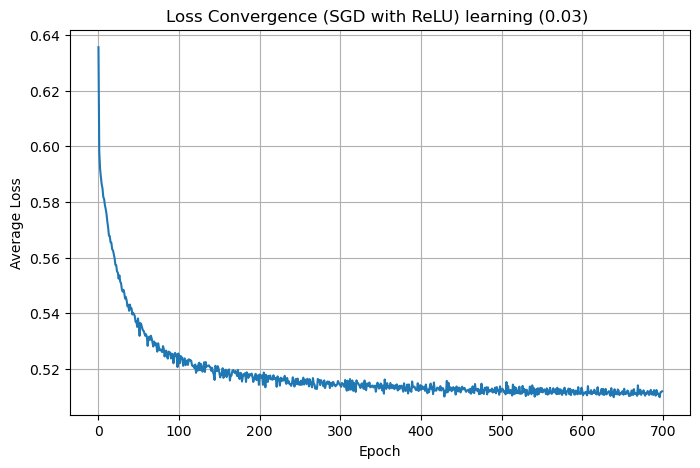

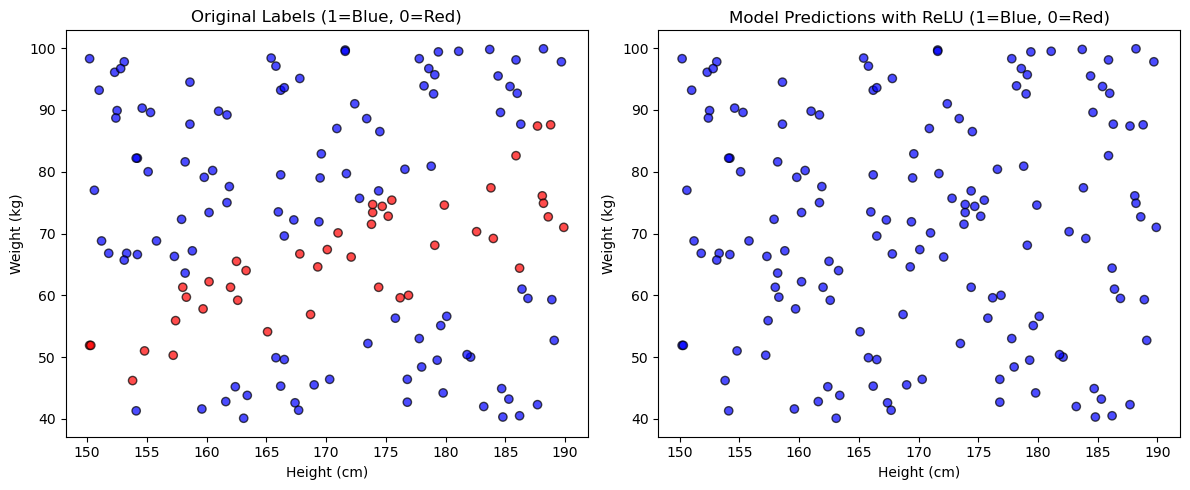

In [79]:
def sigmoid(z):
    return 1 / (1 + np.exp(-np.clip(z, -250, 250)))

def relu(z):
    return np.maximum(0, z)

def sigmoid_derivative(a):
    return a * (1 - a)

def relu_derivative(z):
    return (z > 0).astype(float)

def forward(X, W1, b1, W2, b2):
    Z1 = X @ W1 + b1
    H1 = relu(Z1)  # Changed from tanh to relu
    Z2 = H1 @ W2 + b2
    y_hat = sigmoid(Z2)
    return Z1, H1, Z2, y_hat

def loss(y, y_hat):
    epsilon = 1e-8
    y_hat = np.clip(y_hat, epsilon, 1 - epsilon)
    return -np.mean(y * np.log(y_hat) + (1 - y) * np.log(1 - y_hat))

def backward(X, y, Z1, H1, Z2, y_hat, W2):
    N = X.shape[0]
    dL_dyhat = -(y / y_hat) + ((1 - y) / (1 - y_hat))
    dL_dyhat = np.clip(dL_dyhat, -1e6, 1e6)
    dyhat_dZ2 = sigmoid_derivative(y_hat)
    dL_dZ2 = dL_dyhat * dyhat_dZ2
    dL_dW2 = H1.T @ dL_dZ2 / N
    dL_db2 = np.mean(dL_dZ2, axis=0, keepdims=True)
    dL_dH1 = dL_dZ2 @ W2.T
    dH1_dZ1 = relu_derivative(Z1)  # Changed: use Z1 not H1 for ReLU derivative
    dL_dZ1 = dL_dH1 * dH1_dZ1
    dL_dW1 = X.T @ dL_dZ1 / N
    dL_db1 = np.mean(dL_dZ1, axis=0, keepdims=True)
    return dL_dW1, dL_db1, dL_dW2, dL_db2

def train_sgd(X, y, epochs=300, learning_rate=0.5):
    N = X.shape[0]
    n_features = X.shape[1]
    n_hidden = 2

    # He initialization works better with ReLU
    W1 = np.random.randn(n_features, n_hidden) * np.sqrt(2.0 / n_features)
    b1 = np.zeros((1, n_hidden))
    W2 = np.random.randn(n_hidden, 1) * np.sqrt(2.0 / n_hidden)
    b2 = np.zeros((1, 1))

    loss_history = []

    for epoch in range(epochs):
        indices = np.random.permutation(N)
        X_shuffled = X[indices]
        y_shuffled = y[indices]

        epoch_loss = 0

        for i in range(N):
            xi = X_shuffled[i:i+1]
            yi = y_shuffled[i:i+1]

            Z1, H1, Z2, y_hat = forward(xi, W1, b1, W2, b2)
            epoch_loss += loss(yi, y_hat)

            dW1, db1_grad, dW2, db2_grad = backward(xi, yi, Z1, H1, Z2, y_hat, W2)

            W1 = W1 - learning_rate * dW1
            b1 = b1 - learning_rate * db1_grad
            W2 = W2 - learning_rate * dW2
            b2 = b2 - learning_rate * db2_grad

        loss_history.append(epoch_loss / N)

    return W1, b1, W2, b2, loss_history

W1, b1, W2, b2, loss_history = train_sgd(X, y, epochs=700, learning_rate=0.03)

plt.figure(figsize=(8, 5))
plt.plot(loss_history)
plt.xlabel('Epoch')
plt.ylabel('Average Loss')
plt.title('Loss Convergence (SGD with ReLU) learning (0.03) ')
plt.grid(True)
plt.show()


_, _, _, y_hat = forward(X, W1, b1, W2, b2)
df['Model_Prediction'] = (y_hat >= 0.5).astype(int)



fig, ax = plt.subplots(1, 2, figsize=(12, 5))


ax[0].scatter(df['Height(cm)'], df['Weight(kg)'],
              c=df['Label'], cmap='bwr', alpha=0.7, edgecolors='k')
ax[0].set_title('Original Labels (1=Blue, 0=Red)')
ax[0].set_xlabel('Height (cm)')
ax[0].set_ylabel('Weight (kg)')


ax[1].scatter(df['Height(cm)'], df['Weight(kg)'],
              c=df['Model_Prediction'], cmap='bwr', alpha=0.7, edgecolors='k')
ax[1].set_title('Model Predictions with ReLU (1=Blue, 0=Red)')
ax[1].set_xlabel('Height (cm)')
ax[1].set_ylabel('Weight (kg)')

plt.tight_layout()
plt.show()